<a href="https://colab.research.google.com/github/PpHhao/mall-system/blob/main/stylize.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JoJoGAN: One Shot Face Stylization

In [3]:
#@title Setup. This will take a few minutes.
!git clone https://github.com/mchong6/JoJoGAN.git
%cd JoJoGAN
!pip install tqdm gdown scikit-learn scipy lpips dlib opencv-python wandb
!pip install pydrive  # 添加缺少的模块
!pip install oauth2client  # 可能需要这个认证库
!wget https://github.com/ninja-build/ninja/releases/download/v1.8.2/ninja-linux.zip
!sudo unzip ninja-linux.zip -d /usr/local/bin/
!sudo update-alternatives --install /usr/bin/ninja ninja /usr/local/bin/ninja 1 --force

# 完全移除autoreload相关的代码
# 如果后续代码需要使用自动重载功能，可以用这个替代方案：

import torch
torch.backends.cudnn.benchmark = True
from torchvision import transforms, utils
from util import *
from PIL import Image
import math
import random
import os

import numpy as np
from torch import nn, autograd, optim
from torch.nn import functional as F
from tqdm import tqdm
import wandb
from model import *
from e4e_projection import projection as e4e_projection

from google.colab import files
from copy import deepcopy
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

os.makedirs('inversion_codes', exist_ok=True)
os.makedirs('style_images', exist_ok=True)
os.makedirs('style_images_aligned', exist_ok=True)
os.makedirs('models', exist_ok=True)

Cloning into 'JoJoGAN'...
remote: Enumerating objects: 490, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 490 (delta 31), reused 31 (delta 31), pack-reused 450 (from 1)
Receiving objects: 100% (490/490), 63.51 MiB | 19.55 MiB/s, done.
Resolving deltas: 100% (203/203), done.
/content/JoJoGAN
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 53.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydrive: filename=PyDrive-1.3.1-py3-none-any.whl size=27433 sha256=0ff7dad8530e813c4838d66e7dfe7076f5141450f733447cbed503151563d260
  Stored in directory: /root/.cache/pip/wheels/6c/10/da/a5b513f5b3916fc391c20ee7b4633e5cf3396d570cdd74970f
Successfully built pydrive
--2026-04-13 14:35:21--  https://github.com/ninja-build/ninja/releases/download/v1.8.2/ninja-linux.zip
Resolving github.com (github.com)... 20.205.243.166


In [4]:
#@title Download models
#@markdown You may optionally enable downloads with pydrive in order to authenticate and avoid drive download limits.
download_with_pydrive = False #@param {type:"boolean"}
device = 'cuda' #@param ['cuda', 'cpu']

!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bzip2 -dk shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat models/dlibshape_predictor_68_face_landmarks.dat
%matplotlib inline


drive_ids = {
    "stylegan2-ffhq-config-f.pt": "1Yr7KuD959btpmcKGAUsbAk5rPjX2MytK",
    "e4e_ffhq_encode.pt": "1o6ijA3PkcewZvwJJ73dJ0fxhndn0nnh7",
    "restyle_psp_ffhq_encode.pt": "1nbxCIVw9H3YnQsoIPykNEFwWJnHVHlVd",
    "arcane_caitlyn.pt": "1gOsDTiTPcENiFOrhmkkxJcTURykW1dRc",
    "arcane_caitlyn_preserve_color.pt": "1cUTyjU-q98P75a8THCaO545RTwpVV-aH",
    "arcane_jinx_preserve_color.pt": "1jElwHxaYPod5Itdy18izJk49K1nl4ney",
    "arcane_jinx.pt": "1quQ8vPjYpUiXM4k1_KIwP4EccOefPpG_",
    "arcane_multi_preserve_color.pt": "1enJgrC08NpWpx2XGBmLt1laimjpGCyfl",
    "arcane_multi.pt": "15V9s09sgaw-zhKp116VHigf5FowAy43f",
    "sketch_multi.pt": "1GdaeHGBGjBAFsWipTL0y-ssUiAqk8AxD",
    "disney.pt": "1zbE2upakFUAx8ximYnLofFwfT8MilqJA",
    "disney_preserve_color.pt": "1Bnh02DjfvN_Wm8c4JdOiNV4q9J7Z_tsi",
    "jojo.pt": "13cR2xjIBj8Ga5jMO7gtxzIJj2PDsBYK4",
    "jojo_preserve_color.pt": "1ZRwYLRytCEKi__eT2Zxv1IlV6BGVQ_K2",
    "jojo_yasuho.pt": "1grZT3Gz1DLzFoJchAmoj3LoM9ew9ROX_",
    "jojo_yasuho_preserve_color.pt": "1SKBu1h0iRNyeKBnya_3BBmLr4pkPeg_L",
    "art.pt": "1a0QDEHwXQ6hE_FcYEyNMuv5r5UnRQLKT",
}

# from StyelGAN-NADA
class Downloader(object):
    def __init__(self, use_pydrive):
        self.use_pydrive = use_pydrive

        if self.use_pydrive:
            self.authenticate()

    def authenticate(self):
        auth.authenticate_user()
        gauth = GoogleAuth()
        gauth.credentials = GoogleCredentials.get_application_default()
        self.drive = GoogleDrive(gauth)

    def download_file(self, file_name):
        file_dst = os.path.join('models', file_name)
        file_id = drive_ids[file_name]
        if not os.path.exists(file_dst):
            print(f'Downloading {file_name}')
            if self.use_pydrive:
                downloaded = self.drive.CreateFile({'id':file_id})
                downloaded.FetchMetadata(fetch_all=True)
                downloaded.GetContentFile(file_dst)
            else:
                !gdown --id $file_id -O $file_dst



downloader = Downloader(download_with_pydrive)

downloader.download_file('stylegan2-ffhq-config-f.pt')
downloader.download_file('e4e_ffhq_encode.pt')

latent_dim = 512

# Load original generator
original_generator = Generator(1024, latent_dim, 8, 2).to(device)
ckpt = torch.load('models/stylegan2-ffhq-config-f.pt', map_location=lambda storage, loc: storage)
original_generator.load_state_dict(ckpt["g_ema"], strict=False)
mean_latent = original_generator.mean_latent(10000)

# to be finetuned generator
generator = deepcopy(original_generator)


transform = transforms.Compose(
    [
        transforms.Resize((1024, 1024)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

--2026-04-13 14:37:11--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-04-13 14:37:12--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  14.3MB/s    in 4.9s    

2026-04-13 14:37:17 (12.5 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it an

文件 test_input/img1292_ori.png 可正常读取
Loading e4e over the pSp framework from checkpoint: models/e4e_ffhq_encode.pt


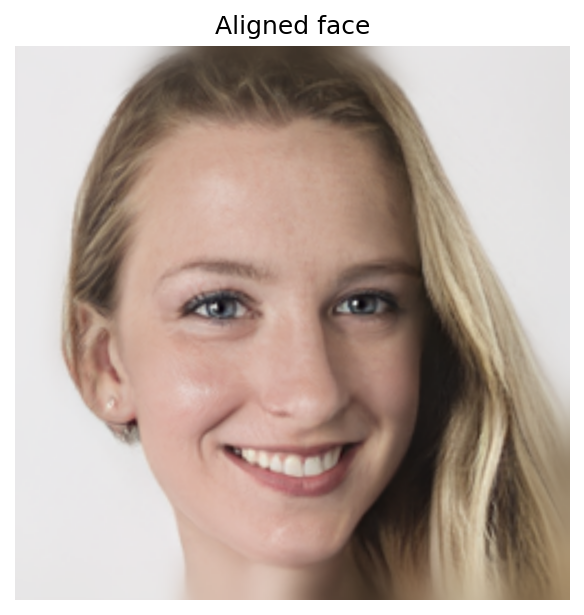

In [34]:
plt.rcParams['figure.dpi'] = 150

#@title Choose input face
#@markdown Add your own image to the test_input directory and put the name here
filename = 'img1292_ori.png' #@param {type:"string"}
filepath = f'test_input/{filename}'

import os
from google.colab import files
from PIL import Image

# 检查文件是否存在
if not os.path.exists(filepath):
    print(f"文件 {filepath} 不存在！")
    print("请上传人脸图片...")

    # 上传文件
    uploaded = files.upload()
    if uploaded:
        # 获取上传的文件名
        filepath = list(uploaded.keys())[0]
        print(f"已上传文件: {filepath}")

        # 如果上传到根目录，移动到test_input目录
        if not filepath.startswith('test_input/'):
            # 确保test_input目录存在
            os.makedirs('test_input', exist_ok=True)
            new_path = f'test_input/{filename}'  # 使用指定的文件名
            os.rename(filepath, new_path)
            filepath = new_path
    else:
        # 如果没有上传，下载默认测试图片
        print("下载默认测试图片...")
        os.makedirs('test_input', exist_ok=True)
        !wget -q -O test_input/img1292_ori.png "https://github.com/mchong6/JoJoGAN/raw/main/test_input/img1292_ori.png"
        filepath = 'test_input/img1292_ori.png'

# 再次检查文件是否存在
if not os.path.exists(filepath):
    raise FileNotFoundError(f"文件 {filepath} 仍然不存在，请检查！")

# 检查文件是否可读
try:
    with open(filepath, 'rb') as f:
        f.read(10)  # 尝试读取前10个字节
    print(f"文件 {filepath} 可正常读取")
except Exception as e:
    print(f"文件 {filepath} 无法读取: {e}")
    # 重新上传
    print("请重新上传图片...")
    uploaded = files.upload()
    filepath = list(uploaded.keys())[0]

name = strip_path_extension(filepath)+'.pt'

# aligns and crops face
aligned_face = align_face(filepath)

# my_w = restyle_projection(aligned_face, name, device, n_iters=1).unsqueeze(0)
my_w = e4e_projection(aligned_face, name, device).unsqueeze(0)

display_image(aligned_face, title='Aligned face')

# Use pretrained styles

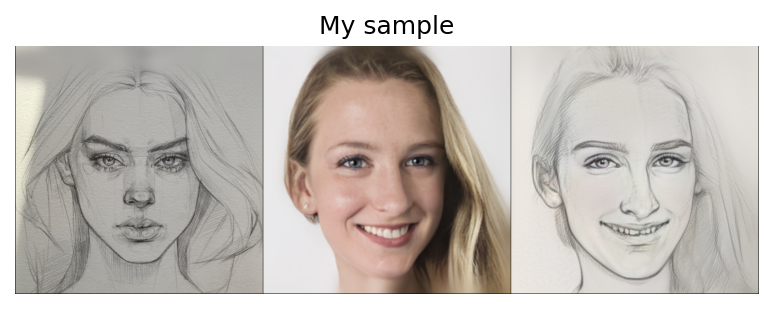

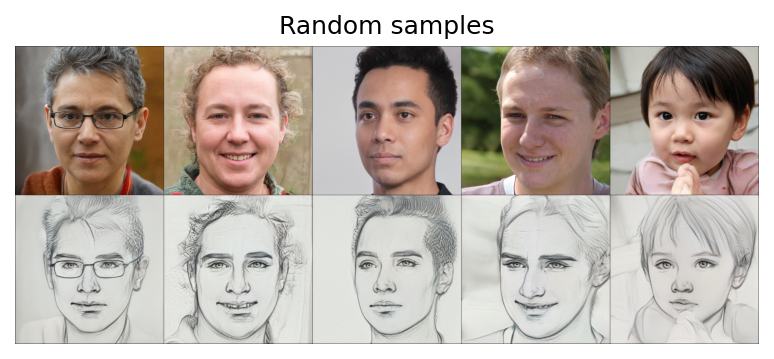

In [14]:
plt.rcParams['figure.dpi'] = 150
pretrained = 'sketch_multi' #@param ['art', 'arcane_multi', 'sketch_multi', 'arcane_jinx', 'arcane_caitlyn', 'jojo_yasuho', 'jojo', 'disney']
#@markdown Preserve color tries to preserve color of original image by limiting family of allowable transformations. Otherwise, the stylized image will inherit the colors of the reference images, leading to heavier stylizations.
preserve_color = False #@param{type:"boolean"}

if preserve_color:
    ckpt = f'{pretrained}_preserve_color.pt'
else:
    ckpt = f'{pretrained}.pt'

# load base version if preserve_color version not available
try:
    downloader.download_file(ckpt)
except:
    ckpt = f'{pretrained}.pt'
    downloader.download_file(ckpt)

ckpt = torch.load(os.path.join('models', ckpt), map_location=lambda storage, loc: storage)
generator.load_state_dict(ckpt["g"], strict=False)

#@title Generate results
n_sample =  5#@param {type:"number"}
seed = 3000 #@param {type:"number"}

torch.manual_seed(seed)
with torch.no_grad():
    generator.eval()
    z = torch.randn(n_sample, latent_dim, device=device)

    original_sample = original_generator([z], truncation=0.7, truncation_latent=mean_latent)
    sample = generator([z], truncation=0.7, truncation_latent=mean_latent)

    original_my_sample = original_generator(my_w, input_is_latent=True)
    my_sample = generator(my_w, input_is_latent=True)

# display reference images
if pretrained == 'arcane_multi':
    style_path = f'style_images_aligned/arcane_jinx.png'
elif pretrained == 'sketch_multi':
    style_path = f'style_images_aligned/sketch.png'
else:
    style_path = f'style_images_aligned/{pretrained}.png'

style_image = transform(Image.open(style_path)).unsqueeze(0).to(device)
face = transform(aligned_face).unsqueeze(0).to(device)

my_output = torch.cat([style_image, face, my_sample], 0)
# display_image(utils.make_grid(my_output, normalize=True, range=(-1, 1)), title='My sample')
display_image(utils.make_grid(my_output, normalize=True, value_range=(-1, 1)), title='My sample')

output = torch.cat([original_sample, sample], 0)
# display_image(utils.make_grid(output, normalize=True, range=(-1, 1), nrow=n_sample), title='Random samples')
display_image(utils.make_grid(output, normalize=True, value_range=(-1, 1), nrow=n_sample), title='Random samples')

# Train with your own style images

开始处理 10 张风格参考图片...

1. 处理: 004_1_1_sz1_aligned.png
  对齐人脸...
  ✓ 人脸对齐完成，保存到: style_images_aligned/004_1_1_sz1_aligned.png
  进行GAN逆投影...
Loading e4e over the pSp framework from checkpoint: models/e4e_ffhq_encode.pt
  ✓ 逆投影完成，潜代码保存到: inversion_codes/004_1_1_sz1_aligned.pt
  ✓ 完成处理: 004_1_1_sz1_aligned.png

2. 处理: 005_1_1_sz1_aligned.png
  对齐人脸...
  ✓ 人脸对齐完成，保存到: style_images_aligned/005_1_1_sz1_aligned.png
  进行GAN逆投影...
Loading e4e over the pSp framework from checkpoint: models/e4e_ffhq_encode.pt
  ✓ 逆投影完成，潜代码保存到: inversion_codes/005_1_1_sz1_aligned.pt
  ✓ 完成处理: 005_1_1_sz1_aligned.png

3. 处理: 020_1_1_sz1_aligned.png
  对齐人脸...
  ✓ 人脸对齐完成，保存到: style_images_aligned/020_1_1_sz1_aligned.png
  进行GAN逆投影...
Loading e4e over the pSp framework from checkpoint: models/e4e_ffhq_encode.pt
  ✓ 逆投影完成，潜代码保存到: inversion_codes/020_1_1_sz1_aligned.pt
  ✓ 完成处理: 020_1_1_sz1_aligned.png

4. 处理: 023_1_1_sz1_aligned.png
  对齐人脸...
  ✓ 人脸对齐完成，保存到: style_images_aligned/023_1_1_sz1_aligned.png
  进行GAN逆投影...
Loadin

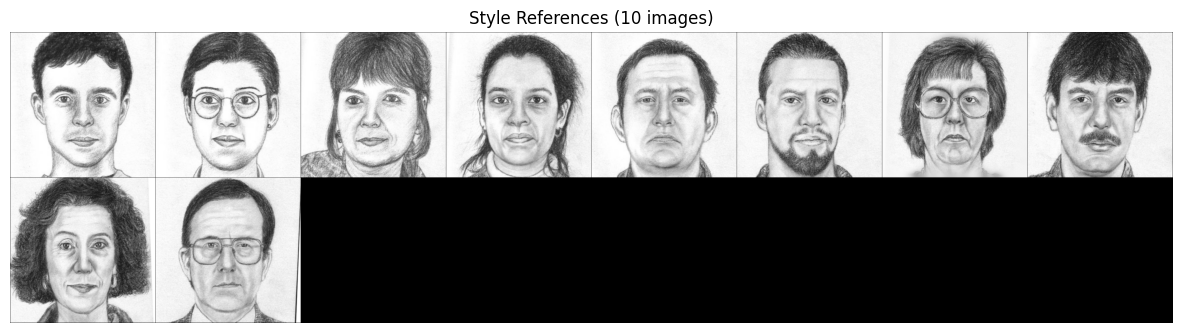


处理结果已准备:
  - 目标图片张量形状: torch.Size([10, 3, 1024, 1024])
  - 潜代码张量形状: torch.Size([10, 18, 512])
  处理结果已保存到 processed_styles.pt


In [6]:
#@markdown Upload your own style images into the style_images folder and type it into the field in the following format without the directory name. Upload multiple style images to do multi-shot image translation
import os
import torch
from PIL import Image
import torchvision.utils as utils
import matplotlib.pyplot as plt
import traceback

# 使用您提供的文件名列表
# names = [
#     '036555_aligned.png',
#     '068879_aligned.png',
#     '084704_aligned.png',
#     '252502_aligned.png',
#     '284387_aligned.png',
#     '287923_aligned.png',
#     '318808_aligned.png',
#     '385780_aligned.png',
#     '470564_aligned.png',
#     '479968_aligned.png'
# ]
# names = [
#     "CFD-AF-200-220-N_aligned.png",
#     "CFD-AF-201-060-N_aligned.png",
#     "CFD-AM-228-214-N_aligned.png",
#     "CFD-WF-023-020-HO_aligned.png",
#     "CFD-BF-233-116-N_aligned.png",
#     "CFD-BF-250-121-N_aligned.png",
#     "CFD-BM-207-024-N_aligned.png",
#     "CFD-BM-239-136-N_aligned.png",
#     "CFD-LF-210-220-N_aligned.png",
#     "CFD-LM-232-204-N_aligned.png"
# ]
names = [
    "004_1_1_sz1_aligned.png",
    "005_1_1_sz1_aligned.png",
    "020_1_1_sz1_aligned.png",
    "023_1_1_sz1_aligned.png",
    "024_1_1_sz1_aligned.png",
    "031_1_1_sz1_aligned.png",
    "035_1_1_sz1_aligned.png",
    "040_1_1_sz1_aligned.png",
    "083_1_1_sz1_aligned.png",
    "276_1_1_sz1_aligned.png"
]

# 确保所需目录存在
os.makedirs('style_images', exist_ok=True)
os.makedirs('style_images_aligned', exist_ok=True)
os.makedirs('inversion_codes', exist_ok=True)

targets = []
latents = []

success_count = 0
failed_count = 0

print(f"开始处理 {len(names)} 张风格参考图片...")

for i, name in enumerate(names, 1):
    style_path = os.path.join('style_images', name)

    # 检查文件是否存在（用更友好的方式替代assert）
    if not os.path.exists(style_path):
        print(f"❌ {i}. 文件不存在: {style_path}")
        failed_count += 1
        continue

    print(f"\n{i}. 处理: {name}")

    # 去掉扩展名
    name_without_ext = strip_path_extension(name)

    # 对齐人脸
    style_aligned_path = os.path.join('style_images_aligned', f'{name_without_ext}.png')

    try:
        if not os.path.exists(style_aligned_path):
            print("  对齐人脸...")
            style_aligned = align_face(style_path)
            if style_aligned is not None:
                style_aligned.save(style_aligned_path)
                print(f"  ✓ 人脸对齐完成，保存到: {style_aligned_path}")
            else:
                print(f"  ✗ 无法对齐图片中的人脸，跳过")
                failed_count += 1
                continue
        else:
            style_aligned = Image.open(style_aligned_path).convert('RGB')
            print(f"  ✓ 使用已对齐的图片: {style_aligned_path}")

        # GAN逆投影
        style_code_path = os.path.join('inversion_codes', f'{name_without_ext}.pt')

        if not os.path.exists(style_code_path):
            print("  进行GAN逆投影...")
            latent = e4e_projection(style_aligned, style_code_path, device)
            print(f"  ✓ 逆投影完成，潜代码保存到: {style_code_path}")
        else:
            latent_data = torch.load(style_code_path, map_location=device)
            # 检查潜代码格式
            if isinstance(latent_data, dict) and 'latent' in latent_data:
                latent = latent_data['latent']
            elif isinstance(latent_data, torch.Tensor):
                latent = latent_data
            else:
                print(f"  ✗ 潜代码格式不正确: {style_code_path}")
                failed_count += 1
                continue
            print(f"  ✓ 加载已有潜代码: {style_code_path}")

        # 转换和添加到列表
        target_tensor = transform(style_aligned).to(device)
        targets.append(target_tensor)
        latents.append(latent.to(device) if isinstance(latent, torch.Tensor) else latent)

        success_count += 1
        print(f"  ✓ 完成处理: {name}")

    except AssertionError as e:
        if "Face not detected" in str(e):
            print(f"  ✗ 错误: 图片中未检测到人脸")
            # 显示有问题的图片
            try:
                img = Image.open(style_path)
                plt.figure(figsize=(6, 6))
                plt.imshow(img)
                plt.title(f"无法检测人脸的图片: {name}")
                plt.axis('off')
                plt.show()
            except:
                pass
        else:
            print(f"  ✗ 断言错误: {e}")
        failed_count += 1

    except Exception as e:
        print(f"  ✗ 处理过程中出错: {e}")
        traceback.print_exc()
        failed_count += 1

# 处理结果总结
print("\n" + "="*60)
print("处理结果总结:")
print(f"  成功处理: {success_count} 张图片")
print(f"  处理失败: {failed_count} 张图片")
print("="*60)

# 如果有成功处理的图片，显示结果
if success_count > 0:
    targets = torch.stack(targets, 0)
    latents = torch.stack(latents, 0)

    # 兼容性处理：torchvision版本差异
    try:
        # 新版本使用value_range
        target_im = utils.make_grid(targets, normalize=True, value_range=(-1, 1))
    except TypeError:
        # 旧版本使用range
        target_im = utils.make_grid(targets, normalize=True, range=(-1, 1))

    # 显示风格参考图片
    plt.figure(figsize=(15, 5))
    plt.imshow(target_im.permute(1, 2, 0).cpu())
    plt.title(f'Style References ({success_count} images)')
    plt.axis('off')
    plt.show()

    # 保存处理结果（可选）
    print(f"\n处理结果已准备:")
    print(f"  - 目标图片张量形状: {targets.shape}")
    print(f"  - 潜代码张量形状: {latents.shape}")

    # 保存到文件（可选）
    torch.save({
        'targets': targets,
        'latents': latents,
        'names': [names[i] for i in range(len(names)) if os.path.exists(os.path.join('style_images', names[i]))]
    }, 'processed_styles.pt')
    print("  处理结果已保存到 processed_styles.pt")
else:
    print("\n⚠️ 警告: 没有成功处理任何图片")
    print("可能的原因:")
    print("  1. 图片文件不存在")
    print("  2. 图片中未检测到人脸")
    print("  3. 图片格式不支持")
    print("  4. 模型加载失败")

    # 提供解决方案
    print("\n建议:")
    print("  1. 确保图片文件在 style_images 目录中")
    print("  2. 确保图片是清晰的人脸正面或轻微侧面照片")
    print("  3. 检查图片格式（支持PNG、JPG、JPEG等）")
    print("  4. 尝试重新上传图片")

    # 如果需要，可以添加上传代码
    from google.colab import files
    upload_new = False  #@param {type:"boolean"}

    if upload_new:
        print("\n请上传新的风格参考图片...")
        uploaded = files.upload()
        if uploaded:
            for filename in uploaded.keys():
                dst_path = os.path.join('style_images', filename)
                os.rename(filename, dst_path)
                print(f"已保存: {dst_path}")
            print("请重新运行此代码单元格处理新上传的图片")

In [ ]:
#@title Finetune StyleGAN (修复版)
#@markdown alpha controls the strength of the style
alpha = 0.8  #@param {type:"slider", min:0, max:1, step:0.1}
alpha = 1 - alpha

#@markdown Tries to preserve color of original image by limiting family of allowable transformations. Set to false if you want to transfer color from reference image. This also leads to heavier stylization
preserve_color = False  #@param{type:"boolean"}
#@markdown Number of finetuning steps. Different style reference may require different iterations. Try 200~500 iterations.
num_iter = 500  #@param {type:"number"}
#@markdown Batch size for training. Reduce to 1 if you have memory issues.
batch_size = 1  #@param {type:"number"}
#@markdown Use gradient accumulation to simulate larger batch size
accumulation_steps = 4  #@param {type:"number"}
#@markdown Disable mixed precision to avoid compatibility issues with custom CUDA ops
use_amp = False  #@param {type:"boolean"}  # 改为 False

# 清理内存
import torch
import gc
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

# 检查必要变量
print("检查必要变量和内存状态...")
if torch.cuda.is_available():
    print(f"GPU内存总量: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"GPU内存已分配: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    print(f"GPU内存缓存: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

# 加载判别器
discriminator = Discriminator(1024, 2).eval().to(device)
ckpt = torch.load('models/stylegan2-ffhq-config-f.pt', map_location=device)
discriminator.load_state_dict(ckpt["d"], strict=False)

# 重置生成器
if 'generator' in locals():
    del generator
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

generator = deepcopy(original_generator)

# 设置优化器
g_optim = optim.Adam(generator.parameters(), lr=2e-3, betas=(0.0, 0.99))

# 确定要交换的层
if preserve_color:
    id_swap = [9, 11, 15, 16, 17]
else:
    id_swap = list(range(7, generator.n_latent))

print(f"批量大小: {batch_size}")
print(f"梯度累积步数: {accumulation_steps}")
print(f"混合精度训练: {use_amp}")

# 训练循环
from tqdm import tqdm
import torch.nn.functional as F

losses = []

for idx in tqdm(range(num_iter), desc="微调进度"):
    total_loss = 0
    g_optim.zero_grad()  # 在累积梯度前清零梯度

    for accum_step in range(accumulation_steps):
        # 随机选择样本
        n_samples = latents.size(0)
        if batch_size >= n_samples:
            indices = torch.arange(n_samples)
        else:
            indices = torch.randperm(n_samples)[:batch_size]

        batch_latents = latents[indices]
        batch_targets = targets[indices]

        # 混合潜在向量
        with torch.no_grad():  # 这部分不需要梯度
            mean_w = generator.get_latent(torch.randn([batch_size, latent_dim]).to(device)).unsqueeze(1).repeat(1, generator.n_latent, 1)

        in_latent = batch_latents.clone()
        in_latent[:, id_swap] = alpha * batch_latents[:, id_swap] + (1 - alpha) * mean_w[:, id_swap]

        # 生成图片
        img = generator(in_latent, input_is_latent=True)

        # 计算感知损失
        with torch.no_grad():
            real_feat = discriminator(batch_targets)
        fake_feat = discriminator(img)

        # 计算损失
        loss = sum([F.l1_loss(a, b) for a, b in zip(fake_feat, real_feat)]) / len(fake_feat)
        loss = loss / accumulation_steps  # 梯度累积

        # 反向传播
        loss.backward()
        total_loss += loss.item()

    # 更新参数
    g_optim.step()

    losses.append(total_loss)

    # 定期清理内存
    if idx % 20 == 0 and idx > 0:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

print(f"\n✅ 微调完成！最终损失: {losses[-1]:.6f}")

检查必要变量和内存状态...
GPU内存总量: 14.56 GB
GPU内存已分配: 0.57 GB
GPU内存缓存: 0.61 GB
批量大小: 1
梯度累积步数: 4
混合精度训练: False


微调进度:   0%|          | 0/500 [00:00<?, ?it/s]/content/JoJoGAN/op/conv2d_gradfix.py:88: UserWarning: conv2d_gradfix not supported on PyTorch 2.10.0+cu128. Falling back to torch.nn.functional.conv2d().
  warnings.warn(
微调进度:  55%|█████▍    | 274/500 [09:51<06:57,  1.85s/it]

In [1]:
#@title 简单批量处理版本（修复版）
#@markdown 只需指定输入目录，程序会自动处理所有图片
input_dir = "my_input"  #@param {type:"string"}
output_dir = "output_stylized"  #@param {type:"string"}

import os
import glob
from PIL import Image
import torch
import numpy as np
from torchvision import transforms
import traceback

# 创建输出目录
os.makedirs(output_dir, exist_ok=True)

# 获取所有图片
image_files = []
for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.gif']:
    image_files.extend(glob.glob(os.path.join(input_dir, ext)))

if not image_files:
    print(f"在 {input_dir} 中没有找到图片文件")
    print("请确保目录中包含以下格式的图片: PNG, JPG, JPEG, BMP, GIF")
else:
    print(f"找到 {len(image_files)} 张图片:")
    for f in image_files:
        print(f"  - {os.path.basename(f)}")

# 定义transform函数（与之前的一致）
transform = transforms.Compose([
    transforms.Resize((1024, 1024)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# 修复的e4e_projection调用函数
def run_e4e_projection(aligned_face, latent_path, device):
    """修复的e4e投影函数，确保传入正确的格式"""
    try:
        # 确保aligned_face是PIL Image
        if not isinstance(aligned_face, Image.Image):
            if isinstance(aligned_face, np.ndarray):
                # 如果是numpy数组，转换为PIL Image
                aligned_face = Image.fromarray(aligned_face.astype('uint8'))
            else:
                # 尝试转换为PIL Image
                aligned_face = Image.fromarray(np.array(aligned_face).astype('uint8'))

        # 确保是RGB模式
        if aligned_face.mode != 'RGB':
            aligned_face = aligned_face.convert('RGB')

        # 调用e4e_projection
        latent = e4e_projection(aligned_face, latent_path, device)
        return latent

    except Exception as e:
        print(f"e4e投影失败: {e}")
        # 尝试使用另一种方法
        try:
            # 将图片保存到临时文件
            temp_path = f"temp_{os.path.basename(latent_path).replace('.pt', '.png')}"
            aligned_face.save(temp_path)

            # 使用文件路径调用
            latent = e4e_projection(temp_path, latent_path, device)

            # 删除临时文件
            if os.path.exists(temp_path):
                os.remove(temp_path)

            return latent
        except Exception as e2:
            print(f"备选方法也失败: {e2}")
            raise

# 批量处理
success_count = 0
failed_count = 0

for img_path in image_files:
    try:
        img_name = os.path.splitext(os.path.basename(img_path))[0]
        print(f"\n{'='*50}")
        print(f"处理: {img_name}")

        # 1. 检查图片是否可读
        try:
            test_img = Image.open(img_path)
            test_img.verify()
            test_img = Image.open(img_path)  # 重新打开
            print(f"  图片验证通过: {test_img.format}, 大小: {test_img.size}")
        except Exception as e:
            print(f"  ❌ 图片文件损坏: {e}")
            failed_count += 1
            continue

        # 2. 对齐人脸
        print("  对齐人脸...")
        aligned_face = align_face(img_path)
        if aligned_face is None:
            print(f"  ❌ 跳过: 无法检测到人脸")
            failed_count += 1
            continue
        else:
            print(f"  ✓ 人脸对齐成功")
            # 确保对齐后的人脸是PIL Image
            if isinstance(aligned_face, np.ndarray):
                aligned_face = Image.fromarray(aligned_face.astype('uint8'))
            elif not isinstance(aligned_face, Image.Image):
                try:
                    aligned_face = Image.fromarray(np.array(aligned_face).astype('uint8'))
                except:
                    print(f"  ❌ 无法转换对齐后的人脸格式")
                    failed_count += 1
                    continue

        # 3. 获取或生成潜代码
        latent_path = os.path.join('inversion_codes', f'{img_name}.pt')

        try:
            if os.path.exists(latent_path):
                print(f"  加载已有的潜代码...")
                latent_data = torch.load(latent_path, map_location=device)
                if isinstance(latent_data, dict) and 'latent' in latent_data:
                    my_w = latent_data['latent'].unsqueeze(0)
                elif isinstance(latent_data, torch.Tensor):
                    my_w = latent_data.unsqueeze(0)
                else:
                    print(f"  ❌ 潜代码格式不正确，重新生成...")
                    raise ValueError("潜代码格式不正确")
            else:
                print(f"  生成新的潜代码...")
                my_w = run_e4e_projection(aligned_face, latent_path, device)
                if my_w is not None:
                    my_w = my_w.unsqueeze(0) if isinstance(my_w, torch.Tensor) else my_w
                else:
                    raise ValueError("e4e投影返回None")

            print(f"  ✓ 潜代码获取成功")

        except Exception as e:
            print(f"  ❌ 获取潜代码失败: {e}")
            failed_count += 1
            continue

        # 4. 生成风格化图片
        print("  生成风格化图片...")
        try:
            with torch.no_grad():
                generator.eval()
                stylized_face = generator(my_w, input_is_latent=True)
            print(f"  ✓ 风格化图片生成成功")
        except Exception as e:
            print(f"  ❌ 风格化生成失败: {e}")
            failed_count += 1
            continue

        # 5. 保存结果
        print("  保存结果...")
        try:
            # 将风格化图片转换为PIL Image
            # 风格化图片的范围是[-1, 1]，需要转换为[0, 1]
            stylized_img = stylized_face.squeeze(0).cpu()  # 移除batch维度
            stylized_img = (stylized_img + 1) / 2  # 从[-1,1]转换到[0,1]
            stylized_img = stylized_img.clamp(0, 1)  # 确保在[0,1]范围内

            # 转换为PIL Image
            stylized_pil = transforms.ToPILImage()(stylized_img)

            # 保存原始图片以供对比
            original_save_path = os.path.join(output_dir, f'{img_name}_original.png')
            aligned_face.save(original_save_path)

            # 保存风格化图片
            save_path = os.path.join(output_dir, f'{img_name}_stylized.png')
            stylized_pil.save(save_path)

            # 保存对比图片（并排显示）
            comparison_img = Image.new('RGB', (aligned_face.width + stylized_pil.width, max(aligned_face.height, stylized_pil.height)))
            comparison_img.paste(aligned_face, (0, 0))
            comparison_img.paste(stylized_pil, (aligned_face.width, 0))
            comparison_save_path = os.path.join(output_dir, f'{img_name}_comparison.png')
            comparison_img.save(comparison_save_path)

            print(f"  ✓ 已保存: {save_path}")
            print(f"  ✓ 对比图: {comparison_save_path}")

            success_count += 1

        except Exception as e:
            print(f"  ❌ 保存结果失败: {e}")
            failed_count += 1
            continue

    except Exception as e:
        print(f"  ❌ 处理过程中发生未知错误: {e}")
        traceback.print_exc()
        failed_count += 1
        continue

# 结果统计
print(f"\n{'='*60}")
print(f"处理完成！")
print(f"✅ 成功处理: {success_count} 张图片")
print(f"❌ 处理失败: {failed_count} 张图片")

if success_count > 0:
    print(f"所有结果保存在: {output_dir}")

    # 显示成功处理的图片列表
    print(f"\n成功处理的图片:")
    for img_path in image_files:
        img_name = os.path.splitext(os.path.basename(img_path))[0]
        stylized_path = os.path.join(output_dir, f'{img_name}_stylized.png')
        if os.path.exists(stylized_path):
            print(f"  ✓ {img_name}")

    # 创建HTML预览文件
    try:
        html_path = os.path.join(output_dir, 'preview.html')
        with open(html_path, 'w', encoding='utf-8') as f:
            f.write('<!DOCTYPE html>\n')
            f.write('<html>\n<head>\n')
            f.write('<title>JoJoGAN 批量处理结果预览</title>\n')
            f.write('<style>\n')
            f.write('body { font-family: Arial, sans-serif; margin: 20px; }\n')
            f.write('.container { max-width: 1200px; margin: 0 auto; }\n')
            f.write('h1 { color: #333; }\n')
            f.write('.image-item { margin: 20px 0; border: 1px solid #ddd; padding: 10px; }\n')
            f.write('.image-item img { max-width: 100%; height: auto; }\n')
            f.write('.filename { font-weight: bold; margin: 10px 0; }\n')
            f.write('</style>\n</head>\n<body>\n')
            f.write('<div class="container">\n')
            f.write('<h1>JoJoGAN 批量处理结果预览</h1>\n')
            f.write(f'<p>成功处理: {success_count} 张图片</p>\n')

            for img_path in image_files:
                img_name = os.path.splitext(os.path.basename(img_path))[0]
                comparison_path = f'{img_name}_comparison.png'
                if os.path.exists(os.path.join(output_dir, comparison_path)):
                    f.write(f'<div class="image-item">\n')
                    f.write(f'<div class="filename">{img_name}</div>\n')
                    f.write(f'<img src="{comparison_path}" alt="{img_name}">\n')
                    f.write('<p>左: 原始图片 | 右: 风格化图片</p>\n')
                    f.write('</div>\n')

            f.write('</div>\n</body>\n</html>')

        print(f"\n📄 预览文件已生成: {html_path}")
        print("   可以在浏览器中打开此文件查看所有对比结果")

    except Exception as e:
        print(f"生成预览文件时出错: {e}")

在 my_input 中没有找到图片文件
请确保目录中包含以下格式的图片: PNG, JPG, JPEG, BMP, GIF

处理完成！
✅ 成功处理: 0 张图片
❌ 处理失败: 0 张图片


In [ ]:
from google.colab import drive
drive.mount('/content/drive')